# 🧠 The Mind of a Model
# Day 6: Overfitting + Underfitting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print('✅ Libraries imported!')

✅ Libraries imported!


In [ ]:
url = 'https://raw.githubusercontent.com/Aeshwa-Kachhadiya/The-mind-of-a-model/main/dataset/linkedin_post_performance.xlsx'

df = pd.read_excel(url)
print('✅ Dataset loaded!')
print(f'Shape: {df.shape}')

✅ Dataset loaded!
Shape: (300, 20)


In [ ]:
binary_cols = ['has_image', 'has_video', 'has_carousel',
               'has_hashtags', 'has_question', 'has_emoji',
               'is_weekend']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['went_viral'] = df['went_viral'].map({'Yes': 1, 'No': 0})

le = LabelEncoder()
df['topic_category'] = le.fit_transform(df['topic_category'])
df['posting_day'] = le.fit_transform(df['posting_day'])

numerical_cols = ['word_count', 'account_followers',
                  'account_age_months', 'posting_frequency',
                  'likes_first_hour', 'comments_first_hour',
                  'shares_first_hour', 'impressions_first_hour']
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

print('✅ Data prepared!')

✅ Data prepared!


/tmp/ipykernel_12971/3617530617.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
X = df.drop(columns=['went_viral'])
y = df['went_viral']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Testing set: {X_test.shape[0]} rows')

Training set: 240 rows
Testing set: 60 rows


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Underfitting → model too simple
# max_depth=1 means the tree can only
# ask ONE question about the data
underfit_model = DecisionTreeClassifier(max_depth=1,
                                        random_state=42)
underfit_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, underfit_model.predict(X_train))
test_acc = accuracy_score(y_test, underfit_model.predict(X_test))

print('UNDERFITTING EXAMPLE:')
print(f'max_depth = 1 (too simple)')
print()
print(f'Training Accuracy : {train_acc:.2%}')
print(f'Testing Accuracy  : {test_acc:.2%}')
print()
print('Both scores are low.')
print('The model is too simple to learn anything.')

UNDERFITTING EXAMPLE:
max_depth = 1 (too simple)

Training Accuracy : 88.75%
Testing Accuracy  : 85.00%

Both scores are low.
The model is too simple to learn anything.


In [ ]:
# Overfitting → model too complex
# max_depth=None means the tree grows
# until it memorizes every single row
overfit_model = DecisionTreeClassifier(max_depth=None,
                                       random_state=42)
overfit_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, overfit_model.predict(X_train))
test_acc = accuracy_score(y_test, overfit_model.predict(X_test))

print('OVERFITTING EXAMPLE:')
print(f'max_depth = None (too complex)')
print()
print(f'Training Accuracy : {train_acc:.2%}')
print(f'Testing Accuracy  : {test_acc:.2%}')
print()
print('Training accuracy is very high.')
print('Testing accuracy is much lower.')
print('The model memorized the training data.')
print('It did not learn from it.')

OVERFITTING EXAMPLE:
max_depth = None (too complex)

Training Accuracy : 100.00%
Testing Accuracy  : 90.00%

Training accuracy is very high.
Testing accuracy is much lower.
The model memorized the training data.
It did not learn from it.


In [ ]:
# Just right → balanced model
# max_depth=5 is a good balance
balanced_model = DecisionTreeClassifier(max_depth=5,
                                        random_state=42)
balanced_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, balanced_model.predict(X_train))
test_acc = accuracy_score(y_test, balanced_model.predict(X_test))

print('BALANCED MODEL:')
print(f'max_depth = 5 (just right)')
print()
print(f'Training Accuracy : {train_acc:.2%}')
print(f'Testing Accuracy  : {test_acc:.2%}')
print()
print('Both scores are close to each other.')
print('The model learned. It did not memorize.')

BALANCED MODEL:
max_depth = 5 (just right)

Training Accuracy : 99.58%
Testing Accuracy  : 90.00%

Both scores are close to each other.
The model learned. It did not memorize.


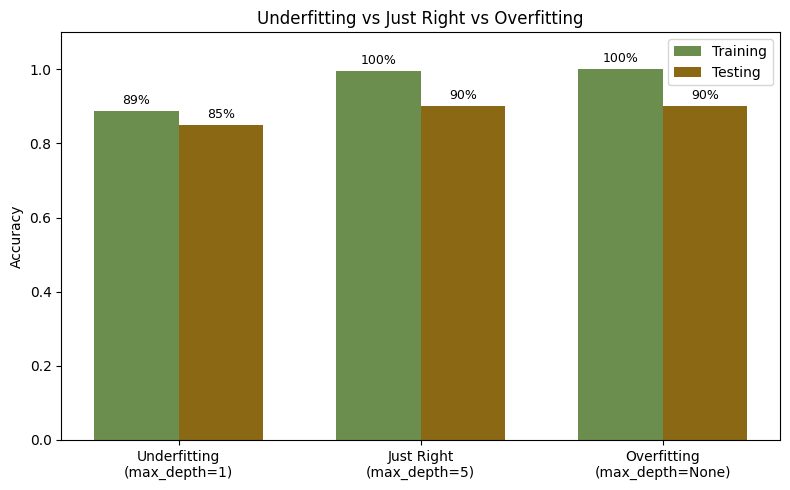

In [ ]:
# Compare all three models visually
models = ['Underfitting\n(max_depth=1)',
          'Just Right\n(max_depth=5)',
          'Overfitting\n(max_depth=None)']

train_scores = [
    accuracy_score(y_train, underfit_model.predict(X_train)),
    accuracy_score(y_train, balanced_model.predict(X_train)),
    accuracy_score(y_train, overfit_model.predict(X_train))
]

test_scores = [
    accuracy_score(y_test, underfit_model.predict(X_test)),
    accuracy_score(y_test, balanced_model.predict(X_test)),
    accuracy_score(y_test, overfit_model.predict(X_test))
]

x = range(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - width/2 for i in x], train_scores,
       width, label='Training', color='#6B8E4E')
ax.bar([i + width/2 for i in x], test_scores,
       width, label='Testing', color='#8B6914')

ax.set_ylabel('Accuracy')
ax.set_title('Underfitting vs Just Right vs Overfitting')
ax.set_xticks(list(x))
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)

for i, (tr, te) in enumerate(zip(train_scores, test_scores)):
    ax.text(i - width/2, tr + 0.02, f'{tr:.0%}',
            ha='center', fontsize=9)
    ax.text(i + width/2, te + 0.02, f'{te:.0%}',
            ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
summary = pd.DataFrame({
    'Model': ['Underfitting', 'Just Right', 'Overfitting'],
    'max_depth': [1, 5, 'None'],
    'Train Accuracy': [
        f'{accuracy_score(y_train, underfit_model.predict(X_train)):.2%}',
        f'{accuracy_score(y_train, balanced_model.predict(X_train)):.2%}',
        f'{accuracy_score(y_train, overfit_model.predict(X_train)):.2%}'
    ],
    'Test Accuracy': [
        f'{accuracy_score(y_test, underfit_model.predict(X_test)):.2%}',
        f'{accuracy_score(y_test, balanced_model.predict(X_test)):.2%}',
        f'{accuracy_score(y_test, overfit_model.predict(X_test)):.2%}'
    ],
    'Problem': ['Too simple', 'Balanced', 'Too complex']
})

print('SUMMARY:')
summary

SUMMARY:


,Model,max_depth,Train Accuracy,Test Accuracy,Problem
0,Underfitting,1,88.75%,85.00%,Too simple
1,Just Right,5,99.58%,90.00%,Balanced
2,Overfitting,None,100.00%,90.00%,Too complex
